# MedNote Agent Graph — Testing the Task 8 Build

A hands-on walkthrough of the **shipped** LangGraph agent (`src/mednote/agent/`):
state schema → intent router → the compiled graph itself → every execution path,
using the Task 4 synthetic transcripts as inputs.

| § | What | Cost |
|---|------|------|
| 1 | Imports + **compiled graph visualization** | free |
| 2 | State schema & `parse_input` intent routing (pure functions) | free |
| 3 | The free paths: `refuse` + the `history` stub | free — no models load |
| 4 | Degradation: transcript below the word floor | free — no models load |
| 5 | `icd_lookup` — live RAG over the real index | 💰 1 Gemini call, loads SapBERT+Qdrant |
| 6 | Full SOAP round trip (TX001) + retrieval cache | 💰 2 Gemini calls per run |
| 7 | Red-flag transcript (TX005) — optional | 💰 2 Gemini calls |
| 8 | **EHR tools live (Tasks 11–13)**: save-path DoD + MCP surface | 💰 2 Gemini calls |
| 9 | Release the Qdrant lock + stop the EHR | free |

> ⚠️ Once §5 runs, this kernel holds the **single-process lock** on
> `data/qdrant_data/` — run §9 (or restart the kernel) before using the CLI
> scripts or another notebook against the index. §8 does **not** need the
> Qdrant index — the save path never touches RAG.

## 0 · Setup

Same defensive setup as the RAG notebook: repo-root discovery, `.env` loaded with
`override=True` (a stale key in the kernel's inherited environment must lose to the
file), and the config cache cleared so a long-lived kernel re-reads `config.yml`.

In [3]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "config.yml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

import os
os.chdir(REPO_ROOT)

from dotenv import load_dotenv
load_dotenv(override=True)
_key = os.getenv("GOOGLE_API_KEY", "")
print(f"GOOGLE_API_KEY loaded: ...{_key[-4:]}" if _key else "GOOGLE_API_KEY MISSING")

from mednote.config import get_config
get_config.cache_clear()
cfg = get_config()
print("main LLM:", cfg.llm.provider, cfg.llm.model)
print("fast LLM:", cfg.llm.fast.provider, cfg.llm.fast.model)
assert cfg.llm.provider == "google", "stale config cached — restart the kernel"

GOOGLE_API_KEY loaded: ...lQ-g
main LLM: google gemini-pro-latest
fast LLM: google gemini-flash-lite-latest


## 1 · Import the agent and visualize the compiled graph

`build_graph()` assembles the `StateGraph` and compiles it. Importing is cheap —
the heavy services (SapBERT, Qdrant, LLM clients) load lazily on first use, not
at import time.

The render below is generated **from the compiled graph object itself**, so what
you see is the actual runtime topology, not documentation. Dashed edges are the
two conditional routers — both read only `state["intent"]`:

- `parse_input` fans out to the five intent paths
- `rag_pipeline` sends `soap` onward to note generation, `icd_lookup` straight
  to response formatting

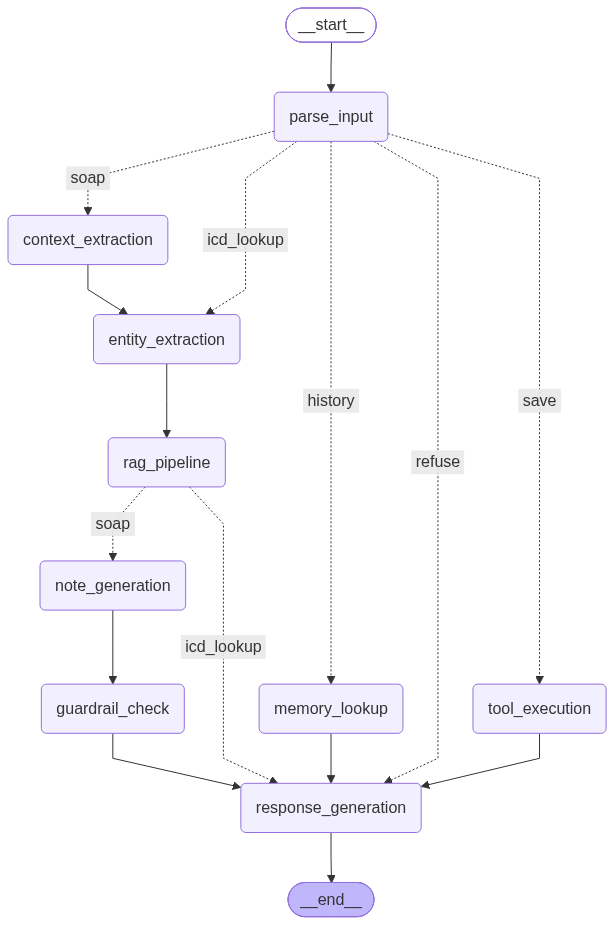

In [4]:
from mednote.agent.graph import build_graph, run_agent

compiled = build_graph()
topology = compiled.get_graph()

# PNG render goes through the mermaid.ink web service; fall back to the
# mermaid source (paste into https://mermaid.live) if offline.
try:
    from IPython.display import Image, display
    display(Image(topology.draw_mermaid_png()))
except Exception as exc:
    print(f"PNG render unavailable ({type(exc).__name__}) — mermaid source:\n")
    print(topology.draw_mermaid())

In [3]:
# The same topology as data: every node and edge of the compiled graph.
print("NODES:", list(topology.nodes))
print("\nEDGES:")
for edge in topology.edges:
    kind = "conditional" if edge.conditional else "direct     "
    print(f"  {kind}  {edge.source:20s} -> {edge.target}")

NODES: ['__start__', 'parse_input', 'context_extraction', 'entity_extraction', 'rag_pipeline', 'note_generation', 'guardrail_check', 'tool_execution', 'memory_lookup', 'response_generation', '__end__']

EDGES:
  direct       __start__            -> parse_input
  direct       context_extraction   -> entity_extraction
  direct       entity_extraction    -> rag_pipeline
  direct       guardrail_check      -> response_generation
  direct       memory_lookup        -> response_generation
  direct       note_generation      -> guardrail_check
  conditional  parse_input          -> context_extraction
  conditional  parse_input          -> entity_extraction
  conditional  parse_input          -> memory_lookup
  conditional  parse_input          -> response_generation
  conditional  parse_input          -> tool_execution
  conditional  rag_pipeline         -> note_generation
  conditional  rag_pipeline         -> response_generation
  direct       tool_execution       -> response_generation
  d

## 2 · State schema and intent routing (pure functions, no models)

`make_initial_state` seeds only the required keys (`total=False` — no wall of
Nones). `parse_input` classifies intent; note the **dialogue guard**: a pasted
transcript is recognized as `soap` *before* keyword matching, because clinical
dialogue routinely contains trigger words — TX005's doctor asks "any **history**
of heart problems?", which the plan's bare keyword sketch would have misrouted
to the `history` intent.

In [5]:
import json

from mednote.agent.nodes import parse_input
from mednote.agent.state import make_initial_state

print("initial state:", make_initial_state("hello", trace_id="demo-1"), "\n")

TX = {t["transcript_id"]: t for t in json.load(
    open("data/transcripts/synthetic_transcripts.json", encoding="utf-8"))}

for tx_id in ("TX001", "TX002", "TX003", "TX004", "TX005", "TX006"):
    entry = TX[tx_id]
    routed = parse_input(make_initial_state(entry["transcript"], "t"))
    ok = "ok " if routed["intent"] == entry["expected_intent"] else "BAD"
    preview = entry["transcript"][:48].replace("\n", " ")
    print(f"[{ok}] {tx_id}  {routed['intent']:10s}  {preview}...")

initial state: {'user_input': 'hello', 'trace_id': 'demo-1', 'errors': []} 

[ok ] TX001  soap        Doctor: Good morning, what brings you in today? ...
[ok ] TX002  icd_lookup  What ICD-10 code fits 'recurrent tension headach...
[ok ] TX003  save        Save this note to the patient's chart....
[ok ] TX004  history     What did I note for this patient's last visit?...
[ok ] TX005  soap        Doctor: Tell me about this pain. Patient: It sta...
[ok ] TX006  refuse      Diagnose this patient's condition for me....


## 3 · The free paths: `refuse` and `history` (free)

These intents never touch RAG or an LLM, so they run instantly.

> **Changed since Week 1:** both former stubs are gone. The `save` path is
> real tool execution (Tasks 11–13 — costs a Gemini call, needs the EHR up,
> moved to **§8**), and `history` now reads real SQLite visit memory
> (Tasks 14–15, `data/memory.db`): on a fresh store it reports "No prior
> visits found"; after §8.3 saves a note, re-running this cell recalls it.

In [6]:
for tx_id in ("TX006", "TX004"):
    final = run_agent(TX[tx_id]["transcript"], patient_id=TX[tx_id]["patient_id"])
    print(f"=== {tx_id} (intent={final['intent']}) ===")
    print(final["final_response"][:220])
    if final["errors"]:
        print(">> errors channel:", final["errors"])
    print()

=== TX006 (intent=refuse) ===
I cannot provide a definitive diagnosis. As a documentation assistant, I offer
suggested differentials as decision support only — the attending physician must
make the final diagnostic determination. If you would like, p

=== TX004 (intent=history) ===
No prior visit records are available yet — visit memory arrives with Tasks 14-15.



## 4 · Degradation: transcript below the word floor (free)

TX018 is 5 words — under `edge_cases.min_transcript_words`. The graph degrades
**before any model loads**: `entity_extraction` short-circuits with an error,
`rag_pipeline` sees no entities and skips retrieval, `note_generation` refuses
to invent a note. No SapBERT, no Qdrant, no Gemini — watch how fast it returns.

In [7]:
import time

t0 = time.perf_counter()
final = run_agent(TX["TX018"]["transcript"])
print(f"({(time.perf_counter() - t0) * 1000:.0f} ms)")
print("final_response:", final["final_response"])
print("errors        :", final["errors"])
print("suggested     :", final.get("suggested_codes"))

(8 ms)
final_response: Insufficient transcript content to generate a reliable note. Please provide the full encounter transcript.
errors        : ['Insufficient transcript content to generate a reliable note. Please provide the full encounter transcript.']
suggested     : []


## 5 · `icd_lookup` — live RAG over the real index 💰

TX002 is the **primary acceptance test** (requirements Q2): *"What ICD-10 code
fits 'recurrent tension headache'?"* This path runs entity extraction (1 Gemini
call) → hybrid retrieval → cross-encoder rerank → specificity expansion, then
formats the codes directly — **note generation is skipped** (see the router).

First run loads SapBERT + opens the 46,887-point Qdrant store (~1 min cold),
and from here the kernel holds the index lock.

In [8]:
t0 = time.perf_counter()
final = run_agent(TX["TX002"]["transcript"])  # 💰 1 fast-LLM call
print(f"({time.perf_counter() - t0:.1f} s, cold)   intent={final['intent']}")
print("entities:", final["extracted_entities"])
print()
print(final["final_response"])

D:\Projects\MedNote\src\mednote\rag\indexer.py:60: UserWarning: Local mode is not recommended for collections with more than 20,000 points. Collection <icd10_codes> contains 46887 points. Consider using Qdrant in Docker or Qdrant Cloud for better performance with large datasets.
  return QdrantClient(path=path or get_config().vector_store.local_path)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

(27.7 s, cold)   intent=icd_lookup
entities: ["What ICD-10 code fits 'recurrent tension headache'?"]

Insufficient data to suggest an accurate ICD-10 code. Please manually assign in EHR.


## 6 · Full SOAP round trip — the Task 8 Definition of Done 💰

TX001 (routine headache, BP 130/85) through the whole pipe: intent → context →
entities → RAG → note generation → guardrail (stub) → response. Demographics are
passed by the caller until the mock EHR lands (Task 11).

Things to check in the output: all five section headers, BP quoted verbatim,
hedged Assessment, and **every suggested code carrying its citation and
"(Pending Physician Confirmation)"**. The suggested codes span the extracted
conditions — the per-entity fairness fix means the chief complaint can't be
crowded out by a co-mentioned condition.

In [8]:
tx = TX["TX001"]
t0 = time.perf_counter()
final = run_agent(  # 💰 2 Gemini calls (entity extraction + note generation)
    tx["transcript"],
    patient_id=tx["patient_id"],
    patient_age=tx["patient_age"],
    patient_sex=tx["patient_sex"],
)
print(f"({time.perf_counter() - t0:.1f} s)   trace_id={final['trace_id']}")
print("entities :", final["extracted_entities"])
print("codes    :", [(c["code"], round(c["confidence"], 2)) for c in final["suggested_codes"]])
print("cache_hit:", final["cache_hit"], "| errors:", final["errors"])
print("\n" + final["final_response"])

(31.1 s)   trace_id=b29249c6-2e73-4d9b-8b7c-57352c5678dd
entities : ['Cephalgia', 'Prehypertension', 'Insomnia']
codes    : [('F51.05', 0.99), ('G47.01', 0.99), ('G44.099', 0.96)]
cache_hit: False | errors: []

### Subjective
**Chief Complaint:** Headache.
**History of Present Illness:** The patient reports a headache with an onset of approximately three days ago. The character of the pain is described as pressure, located mostly across the forehead. The patient notes the headache is worse in the mornings and eases slightly by the afternoon. 
**Associated Symptoms:** The patient denies nausea, vomiting, vision changes, fever, and neck stiffness. 
**Additional History:** The patient reports sleeping less than usual recently, attributing this to a hectic work schedule. 
**Medications:** Not documented.

### Objective
**Vital Signs:** 
- Blood Pressure: 130/85
**Examination Findings:** Not documented.
**Test Results:** Not documented.

### Assessment
- Headache: The presentation of forehe

In [9]:
# Same request again: retrieval is served from RAGCache (cache_hit flips to
# True). The two LLM calls still happen — caching those is later work. 💰
t0 = time.perf_counter()
again = run_agent(tx["transcript"], patient_age=tx["patient_age"], patient_sex=tx["patient_sex"])
print(f"({time.perf_counter() - t0:.1f} s, warm)   cache_hit: {again['cache_hit']}")

(26.1 s, warm)   cache_hit: True


## 7 · Optional: red-flag transcript 💰

TX005 — chest pain radiating to the left arm with diaphoresis. The
**deterministic** guardrail is still a stub (Task 18), but the SOAP system
prompt independently instructs escalation-first output, so the note should
*lead* with an urgent-escalation warning before the draft. Skip this cell if
you're saving quota.

In [10]:
tx5 = TX["TX005"]
final = run_agent(  # 💰 2 Gemini calls
    tx5["transcript"], patient_age=tx5["patient_age"], patient_sex=tx5["patient_sex"]
)
print("codes:", [(c["code"], round(c["confidence"], 2)) for c in final["suggested_codes"]])
print()
print(final["final_response"][:900])

codes: [('I21.9', 1.0), ('I20.9', 1.0), ('R06.00', 0.99), ('R61', 0.8)]

URGENT ESCALATION: The transcript contains red flag symptoms including chest pressure radiating to the left arm, accompanied by sweating and shortness of breath. Immediate in-person emergency evaluation for possible acute coronary syndrome is recommended.

### Subjective
The patient reports the onset of heavy pressure in the middle of the chest that began approximately one hour ago. The pain radiates down the left arm. Associated symptoms include profuse sweating and shortness of breath. Family history is notable for the patient's father having a coronary bypass at age 60. Medications are not documented. 

### Objective
Not documented.

### Assessment
Patient presenting with acute chest pressure radiating to the left arm, accompanied by diaphoresis and dyspnea. The differential includes possible acute coronary syndrome, acute myocardial infarction, or angina pectoris. 

### Plan
Not docu


## 8 · EHR tools live — the Task 13 Definition of Done 💰

Tasks 11–13 replaced the §3-era save stub: `tool_execution` now invokes the
main LLM **bound to the EHR tools** (`save_note`, `get_patient_history`) under
`TOOL_SYSTEM_PROMPT`, executes whichever tool call the model emits, and maps
the EHR's reply onto a typed `ToolResult`. This section tests whether the
agent can actually *use* the tools:

1. Start the mock EHR inside this kernel (free)
2. `context_extraction` pulls demographics from it (free, no LLM)
3. **The DoD round-trip**: *"Save this note to patient P001's chart"* → LLM
   tool call → `note_id` returned 💰
4. The decline branch: a save request with **no** note content 💰
5. Verify the note landed in the EHR store **and** was mirrored into visit
   memory — the Task 15 save→recall loop (free)
6. The same tools on the MCP surface (free)

> Two caveats worth knowing before running:
> - `parse_input` classifies >40-word inputs as `soap` (transcript heuristic),
>   so the inline note in step 3 is deliberately short. The UI's Save button
>   (Task 16) will pass the generated `draft_note` through state instead —
>   no word limit there.
> - Since Tasks 14–15, a successful save also writes SQLite visit memory
>   (`data/memory.db`), so the `history` intent in step 5 genuinely recalls
>   what step 3 saved — across kernel restarts too.

In [9]:
# 8.1 · Start the mock EHR in a daemon thread (free) — §9 stops it.
import threading
import time

import httpx
import uvicorn

ehr_cfg = get_config().ehr_api
EHR_BASE = f"http://{ehr_cfg.host}:{ehr_cfg.port}"

ehr_server = uvicorn.Server(uvicorn.Config(
    "mednote.tools.ehr_api:app",
    host=ehr_cfg.host, port=ehr_cfg.port, log_level="warning",
))
ehr_thread = threading.Thread(target=ehr_server.run, daemon=True)
ehr_thread.start()

for _ in range(50):
    try:
        httpx.get(f"{EHR_BASE}/patients/P001", timeout=0.5)
        break
    except httpx.HTTPError:
        time.sleep(0.2)
else:
    raise RuntimeError(f"EHR did not come up on {EHR_BASE} — port already in use?")

print("Mock EHR serving at", EHR_BASE)

ERROR:    [Errno 10048] error while attempting to bind on address ('::1', 8100, 0, 0): only one usage of each socket address (protocol/network address/port) is normally permitted


Mock EHR serving at http://localhost:8100


In [10]:
# 8.2 · context_extraction now asks the EHR for demographics (free, no LLM).
from mednote.agent.nodes import context_extraction

# No caller demographics -> the node fetches them by patient_id (Task 11):
print("from EHR    :", context_extraction({"user_input": "x", "patient_id": "P005"}))

# Caller-supplied demographics always win — no EHR call happens:
print("caller wins :", context_extraction(
    {"user_input": "x", "patient_id": "P005", "patient_sex": "male", "patient_age": 4}
))

from EHR    : {'patient_sex': 'male', 'patient_age': 4}
caller wins : {}


In [11]:
# 8.3 · The DoD round-trip 💰 1 Gemini call: the LLM reads the bound tool
# schemas, extracts patient + note from the request, and emits the tool call.
# (Inline note kept under 40 words — see the section caveat.)
final = run_agent(
    "Save this note to patient P001's chart: Patient reports mild tension "
    "headache, resolved with rest. BP 130/85. Follow-up if it recurs.",
    patient_id="P001",
)

print("intent  :", final["intent"])
print("ok      :", final["tool_result"]["ok"])
print("note_id :", final["tool_result"]["note_id"])
print("reply   :", final["final_response"])

assert final["intent"] == "save"
assert final["tool_result"]["ok"] and final["tool_result"]["note_id"], "DoD FAILED"
print("\n✅ Task 13 DoD: save request -> LLM tool call -> note_id returned")

intent  : save
ok      : True
note_id : N_a905e3d0
reply   : Note saved to patient P001's chart (note ID N_a905e3d0).

✅ Task 13 DoD: save request -> LLM tool call -> note_id returned


In [12]:
# 8.4 · The decline branch 💰 1 Gemini call: same request but NO note content.
# TOOL_SYSTEM_PROMPT forbids inventing patient IDs or note text, so the model
# should make no tool call — and nothing gets written to the EHR.
final = run_agent("Save this note to the patient's chart.", patient_id="P001")

print("ok    :", final["tool_result"]["ok"])
print("reply :", final["final_response"])
print("errors:", final["errors"])

assert final["tool_result"]["ok"] is False and final["tool_result"]["note_id"] is None
print("\n✅ Guardrail held: no content provided -> nothing saved, honest reply")

ok    : False
reply : I cannot save the note because the note content is missing from the request. Please provide the draft note you would like to save.
errors: ['I cannot save the note because the note content is missing from the request. Please provide the draft note you would like to save.']

✅ Guardrail held: no content provided -> nothing saved, honest reply


In [ ]:
# 8.5 · Verify the save landed in BOTH stores (free).
# EHR store (system of record) — via the get_patient_history tool:
from mednote.tools import get_patient_history

hist = get_patient_history.invoke({"patient_id": "P001"})
print("EHR tool     ->", hist["status"], f"| {len(hist.get('visits', []))} visit(s)")
for v in hist.get("visits", [])[-3:]:
    print("   -", v["date"], v["note_id"], v["icd_codes"], "|", v["note"][:60])

# Visit memory (agent's own recall, Tasks 14-15) — via the history INTENT.
# tool_execution mirrored the 8.3 save into SQLite, so the graph now
# genuinely answers "what did I note last visit?" from memory:
final = run_agent("What did I note for this patient's last visit?", patient_id="P001")
print("\nhistory intent ->", final["final_response"])

In [14]:
# 8.6 · The same two tools on the MCP surface (free) — what external hosts
# (Claude Desktop / Inspector) see via tools/list. Full MCP walkthrough incl.
# the stdio wire: docs/notebooks/mcp_tools.ipynb
from mednote.mcp.server import mcp as mcp_server

tools = await mcp_server.list_tools()
for t in tools:
    print(f"── {t.name}: {t.description.strip().splitlines()[0]}")
    print("   required args:", t.inputSchema.get("required"))

── save_note: Save a clinical note to the patient's EHR chart.
   required args: ['patient_id', 'note']
── get_patient_history: Retrieve prior visit notes and history for a patient from the EHR.
   required args: ['patient_id']


## 9 · Release the Qdrant lock (and stop the EHR)

If §5+ ran, the lazily-built RAG pipeline holds the embedded Qdrant store open.
Close it (or restart the kernel) before running CLI scripts or the other
notebook against `data/qdrant_data/`. Also stops the §8 EHR thread if it was
started (the EHR holds no lock — its JSON store is opened per request — so
that part is just tidiness).

In [16]:
from mednote.agent import nodes

if nodes.close_rag_pipeline():
    print("Embedded Qdrant closed — lock on data/qdrant_data/ released.")
else:
    print("RAG pipeline was never built in this kernel — nothing to close.")

try:
    ehr_server.should_exit = True
    print("EHR server stopping.")
except NameError:
    pass  # §8 never ran in this kernel

RAG pipeline was never built in this kernel — nothing to close.
EHR server stopping.
